# Vitara AI — Vision Training Pipeline (v10)

> **Dataset Contract Ref:** Dataset Vision — Food Images  
> **Target Output:** `models/vision_model/`, `models/vision_model.tflite`  
> **Runtime:** Google Colab T4 GPU


## 1. Setup & Dependencies


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

print(f"TensorFlow version: {tf.__version__}")
if tf.config.list_physical_devices('GPU'):
    print("GPU is available!")
else:
    print("GPU is NOT available.")


TensorFlow version: 2.20.0
GPU is NOT available.


## 1.5 Setup Custom Modules (Vitara AI)
Clone repository untuk menggunakan komponen custom yang sudah dibuat.

In [2]:
import sys
import os
from getpass import getpass

# Meminta GitHub Personal Access Token (PAT) secara aman (karena repo private)
print("Masukkan GitHub Personal Access Token (PAT) Anda:")
token = getpass()

# Setup URL clone dengan token
repo_url = f"https://{token}@github.com/Vitara-hub/vitara-ai.git"

!rm -rf vitara-ai
!git clone {repo_url}

# Hapus token dari memory untuk keamanan
del token

# Setup Path untuk custom module
service_path = '/content/vitara-ai/vitara-ai-service'
if service_path not in sys.path:
    sys.path.append(service_path)
    print("✅ Berhasil menambahkan path vitara-ai-service ke sys.path")

Masukkan GitHub Personal Access Token (PAT) Anda:
··········
Cloning into 'vitara-ai'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 150 (delta 90), reused 84 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 9.21 MiB | 9.52 MiB/s, done.
Resolving deltas: 100% (90/90), done.
✅ Berhasil menambahkan path vitara-ai-service ke sys.path


## 2. Mount Google Drive & Config


In [3]:
from google.colab import drive
drive.mount('/content/drive')

GDRIVE_ROOT   = "/content/drive/MyDrive/vitara"
PROCESSED_DIR = os.path.join(GDRIVE_ROOT, "data/vision/processed")
LOG_DIR       = os.path.join(GDRIVE_ROOT, "logs/vision")
MODELS_DIR    = os.path.join(GDRIVE_ROOT, "models")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
MAX_CALORIES = 1000.0  # Constant used for normalization


Mounted at /content/drive


## 3. Unzip Dataset
Mengekstrak dataset gambar yang sudah di-split (Train, Val, Test) dari file zip.


In [4]:
import zipfile
import os

ZIP_PATH = os.path.join(GDRIVE_ROOT, "data/vision/processed/dataset_food_final.zip")
EXTRACT_DIR = "/content/dataset"

print(f"Unzipping {ZIP_PATH} to {EXTRACT_DIR}...")
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print("Unzip complete!")


Unzipping /content/drive/MyDrive/vitara/data/vision/processed/dataset_food_final.zip to /content/dataset...
Unzip complete!


## 4. Data Augmentation & Generators
Menggunakan `ImageDataGenerator` untuk augmentasi data latih dan preprocessing (resize, normalisasi MobileNetV2).


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import pandas as pd

# Updated paths matching the deeper nested folder structure
train_dir = os.path.join(EXTRACT_DIR, 'data', 'vision', 'split', 'train')
val_dir = os.path.join(EXTRACT_DIR, 'data', 'vision', 'split', 'val')
test_dir = os.path.join(EXTRACT_DIR, 'data', 'vision', 'split', 'test')

# ImageDataGenerator dengan augmentasi untuk training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ImageDataGenerator HANYA preprocessing untuk validasi & testing
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")

# --- Multi-Output Wrapper ---
# Membaca map kalori dari dataset mentah
calorie_df = pd.read_csv(os.path.join(GDRIVE_ROOT, "data/vision/raw/calorie_map.csv"))
class_to_calorie = dict(zip(calorie_df['class_name'], calorie_df['calories_per_100g']))

# Mapping dari index class generator ke nilai kalori (dinormalisasi)
idx_to_calorie = {v: class_to_calorie[k] / MAX_CALORIES for k, v in train_generator.class_indices.items()}

class MultiOutputSequence(keras.utils.Sequence):
    def __init__(self, generator, idx_to_calorie):
        self.generator = generator
        self.idx_to_calorie = idx_to_calorie

    def __len__(self):
        return len(self.generator)

    def __getitem__(self, index):
        x, y = self.generator[index]
        calories = np.array([self.idx_to_calorie[int(label)] for label in y])
        return x, {'classification_head': y, 'calorie_head': calories}

    def on_epoch_end(self):
        self.generator.on_epoch_end()

train_ds = MultiOutputSequence(train_generator, idx_to_calorie)
val_ds = MultiOutputSequence(val_generator, idx_to_calorie)
test_ds = MultiOutputSequence(test_generator, idx_to_calorie)


Found 8887 images belonging to 24 classes.
Found 1105 images belonging to 24 classes.
Found 1121 images belonging to 24 classes.
Number of classes: 24


## 4.5 Dataset Statistics

In [6]:
print("--- Calorie Map Statistics ---")
display(calorie_df.head())
print(f"Shape of calorie_df: {calorie_df.shape}")
print("Descriptive statistics for calories_per_100g:")
display(calorie_df['calories_per_100g'].describe())

print("\n--- Dataset Split Statistics ---")
print(f"Number of classes: {num_classes}")
print(f"Number of training images: {train_generator.samples}")
print(f"Number of validation images: {val_generator.samples}")
print(f"Number of test images: {test_generator.samples}")


--- Calorie Map Statistics ---


,class_name,calories_per_100g
0,Mie Goreng,468
1,Nasi Goreng,276
2,gudeg,53
3,Bakso,76
4,Burger,258


Shape of calorie_df: (24, 2)
Descriptive statistics for calories_per_100g:


,calories_per_100g
count,24.000000
mean,219.833333
std,120.340700
min,53.000000
25%,131.500000
50%,202.500000
75%,267.750000
max,520.000000



--- Dataset Split Statistics ---
Number of classes: 24
Number of training images: 8887
Number of validation images: 1105
Number of test images: 1121


## 4.6 Class Distribution Statistics

--- Image Count per Class ---


,Class_ID,Class_Name,Count
11,11,Nasi Goreng,719
20,20,Sate,640
18,18,Rawon,639
21,21,Soto,638
8,8,Gado-Gado,624


,Class_ID,Class_Name,Count
0,0,Ayam Geprek,56
5,5,Capcay,64
13,13,Nasi Uduk,67
15,15,Pecel,68
22,22,Tempe Goreng,72


/tmp/ipykernel_926/31600134.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class_Name', y='Count', data=class_distribution_df.sort_values(by='Count', ascending=False), palette='viridis')


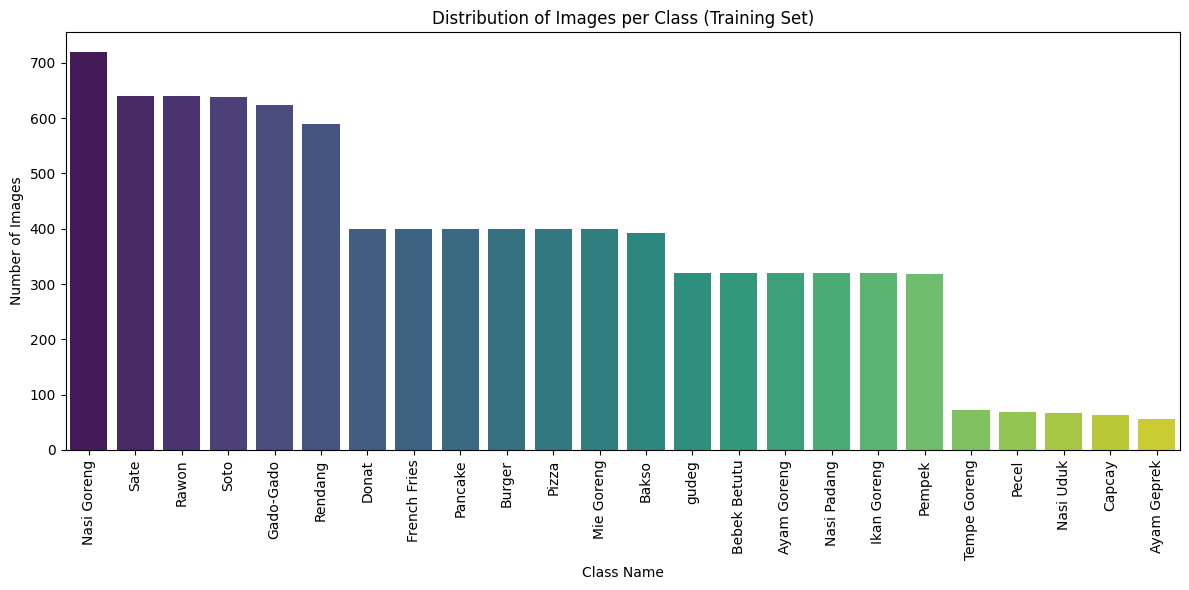

In [9]:
class_labels = list(train_generator.class_indices.keys())
class_counts = pd.Series(train_generator.classes).value_counts().sort_index()

class_distribution_df = pd.DataFrame({
    'Class_ID': class_counts.index,
    'Class_Name': [class_labels[i] for i in class_counts.index],
    'Count': class_counts.values
})

print("--- Image Count per Class ---")
display(class_distribution_df.sort_values(by='Count', ascending=False).head())
display(class_distribution_df.sort_values(by='Count', ascending=True).head())

# Visualize the class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x='Class_Name', y='Count', data=class_distribution_df.sort_values(by='Count', ascending=False), palette='viridis')
plt.xticks(rotation=90)
plt.title('Distribution of Images per Class (Training Set)')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

## 5. Build Model Architecture (Functional API)
`MobileNetV2 (pretrained, freeze awal) → GlobalAveragePooling2D → Dense → [classification_head (softmax), calorie_head (linear)]`


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze awal

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
# Branch Klasifikasi
class_x = layers.Dense(256, activation='relu')(x)
class_x = layers.BatchNormalization()(class_x)
class_x = layers.Dropout(0.3)(class_x)
classification_head = layers.Dense(num_classes, activation='softmax', name='classification_head')(class_x)

# Branch Regresi Kalori (Deterministic Mapping via Softmax)
# Membuat weight matrix berisi nilai kalori setiap kelas
import numpy as np
calorie_weights = np.array([idx_to_calorie[i] for i in range(num_classes)], dtype=np.float32).reshape(num_classes, 1)

# Layer ini tidak memiliki parameter yang dilatih (trainable=False)
# Fungsinya hanya melakukan dot product: Probabilitas Softmax * Kalori Kelas
calorie_head = layers.Dense(
    1,
    activation='linear',
    use_bias=False,
    trainable=False,
    name='calorie_head'
)(classification_head)

model = Model(inputs=inputs, outputs=[classification_head, calorie_head])

# Set weights for calorie_head explicitly to fix Keras 3 TypeError/ValueError
model.get_layer('calorie_head').set_weights([calorie_weights])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head (Dense)     │ (None, 24)             │         6,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ calorie_head (Dense)            │ (None, 1)              │            24 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,136 (9.89 MB)

 Trainable params: 334,616 (1.28 MB)

 Non-trainable params: 2,258,520 (8.62 MB)

## 6. Compile Model


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        'classification_head': 'sparse_categorical_crossentropy',
        'calorie_head': 'mae'
    },
    metrics={
        'classification_head': 'accuracy',
        'calorie_head': 'mae'
    },
    loss_weights={
        'classification_head': 1.0,
        'calorie_head': 0.0  # Mute calorie loss sepenuhnya agar tidak mengganggu gradien akurasi klasifikasi (seperti v7)
    }
)

import sys
import os
service_path = '/content/vitara-ai/vitara-ai-service'
if service_path not in sys.path:
    sys.path.insert(0, service_path) # Pakai insert(0) agar path kita jadi prioritas utama

if not os.path.exists(f"{service_path}/models/custom_callbacks.py"):
    raise FileNotFoundError("❌ ERROR: File custom_callbacks.py TIDAK DITEMUKAN")

sys.path.insert(0, f"{service_path}/models") # Masukkan folder models langsung ke path
from custom_callbacks import VitaraTrainingLogger
v_logger = VitaraTrainingLogger(log_frequency=1)

callbacks = [
    keras.callbacks.TensorBoard(log_dir=LOG_DIR),
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(filepath=os.path.join(MODELS_DIR, 'vision_model_best.keras'), save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    v_logger
]


## 7. Initial Training


In [ ]:
EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=0,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


🚀 [Vitara AI] Training Started at 2026-05-06 23:37:48 WIB
Epoch 001 | 198.8s | calorie_head_loss: 0.0480 | calorie_head_mae: 0.0480 | classification_head_accuracy: 0.6364 | classification_head_loss: 1.3016 | loss: 1.3016 | val_calorie_head_loss: 0.0387 | val_calorie_head_mae: 0.0379 | val_classification_head_accuracy: 0.7403 | val_classification_head_loss: 0.9208 | val_loss: 0.9161 | learning_rate: 0.0010
Epoch 002 | 148.8s | calorie_head_loss: 0.0356 | calorie_head_mae: 0.0356 | classification_head_accuracy: 0.7492 | classification_head_loss: 0.8305 | loss: 0.8302 | val_calorie_head_loss: 0.0356 | val_calorie_head_mae: 0.0353 | val_classification_head_accuracy: 0.7330 | val_classification_head_loss: 0.9221 | val_loss: 0.9235 | learning_rate: 0.0010
Epoch 003 | 148.7s | calorie_head_loss: 0.0319 | calorie_head_mae: 0.0319 | classification_head_accuracy: 0.7807 | classification_head_loss: 0.7048 | loss: 0.7053 | val_calorie_head_loss: 0.0342 | val_calorie_head_mae: 0.0334 | val_classifi

## 8. Fine-Tuning
Unfreeze layer atas MobileNetV2 setelah epoch awal konvergen.


In [ ]:
base_model.trainable = True
# Unfreeze seluruh layer MobileNetV2 untuk memaksimalkan adaptasi fitur
# for layer in base_model.layers[:-100]:
#     layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), # FT learning rate
    loss={
        'classification_head': 'sparse_categorical_crossentropy',
        'calorie_head': 'mae'
    },
    metrics={
        'classification_head': 'accuracy',
        'calorie_head': 'mae'
    },
    loss_weights={
        'classification_head': 1.0,
        'calorie_head': 0.0 # 0.0 memastikan model murni belajar klasifikasi 100%
    }
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    verbose=0,
    callbacks=callbacks
)


🚀 [Vitara AI] Training Started at 2026-05-07 00:27:22 WIB
Epoch 001 | 250.3s | calorie_head_loss: 0.0330 | calorie_head_mae: 0.0330 | classification_head_accuracy: 0.7532 | classification_head_loss: 0.8250 | loss: 0.8251 | val_calorie_head_loss: 0.0368 | val_calorie_head_mae: 0.0364 | val_classification_head_accuracy: 0.7249 | val_classification_head_loss: 1.3638 | val_loss: 1.3690 | learning_rate: 0.0001
Epoch 002 | 153.6s | calorie_head_loss: 0.0220 | calorie_head_mae: 0.0220 | classification_head_accuracy: 0.8473 | classification_head_loss: 0.4707 | loss: 0.4705 | val_calorie_head_loss: 0.0296 | val_calorie_head_mae: 0.0293 | val_classification_head_accuracy: 0.7656 | val_classification_head_loss: 0.9739 | val_loss: 0.9772 | learning_rate: 0.0001
Epoch 003 | 155.7s | calorie_head_loss: 0.0163 | calorie_head_mae: 0.0163 | classification_head_accuracy: 0.8949 | classification_head_loss: 0.3310 | loss: 0.3311 | val_calorie_head_loss: 0.0310 | val_calorie_head_mae: 0.0302 | val_classifi

## 9. Evaluation
Target metrik: Classification Accuracy ≥ 85%, Calorie MAE ≤ 0.02


In [ ]:
print("Evaluating on test set...")

# 1. Pass return_dict=True to get a dictionary mapping names to values
results = model.evaluate(test_ds, return_dict=True)

# 2. Iterate through the dictionary directly
for name, value in results.items():
    print(f"{name}: {value:.4f}")

print("-" * 30)

# 3. Access the specific metrics using their dictionary keys
# (These keys match the names printed in your progress bar)
class_acc = results.get('classification_head_accuracy', 0)
cal_mae = results.get('calorie_head_mae', 0)

print(f"Classification Accuracy: {class_acc * 100:.2f}% (Target: >= 85%)")
print(f"Calorie MAE (Normalized): {cal_mae:.4f} (Target: <= 0.02)")

Evaluating on test set...
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 494ms/step - calorie_head_loss: 0.0176 - calorie_head_mae: 0.0176 - classification_head_accuracy: 0.8555 - classification_head_loss: 0.5730 - loss: 0.5823
calorie_head_loss: 0.0176
calorie_head_mae: 0.0176
classification_head_accuracy: 0.8555
classification_head_loss: 0.5730
loss: 0.5823
------------------------------
Classification Accuracy: 85.55% (Target: >= 85%)
Calorie MAE (Normalized): 0.0176 (Target: <= 0.02)


## 10. Export Model


In [ ]:
export_dir = os.path.join(MODELS_DIR, 'vision_model')
model.export(export_dir)
print(f"SavedModel exported to {export_dir}")

converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
# converter.optimizations = [tf.lite.Optimize.DEFAULT] # Uncomment for quantization
tflite_model = converter.convert()

tflite_path = os.path.join(MODELS_DIR, 'vision_model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"TFLite model exported to {tflite_path}")

# Export classes.txt
classes = list(train_generator.class_indices.keys())
classes_path = os.path.join(MODELS_DIR, 'classes.txt')
with open(classes_path, 'w') as f:
    for c in classes:
        f.write(f"{c}\n")
print(f"Classes exported to {classes_path}")


Saved artifact at '/content/drive/MyDrive/vitara/models/vision_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  List[TensorSpec(shape=(None, 24), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  137542610183248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137542610182864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137542610185552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137542610185168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137542610184016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137542610185744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137542610184208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137542610186320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137542610185936: TensorSpec(shape=(), dtype=tf.resou

## 11. Download dari Colab


In [ ]:
import shutil
from google.colab import files

zip_path = os.path.join(GDRIVE_ROOT, "vision_model.zip")
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', export_dir)
print(f"Zipped SavedModel to {zip_path}")

# Uncomment lines below to download directly to local machine
files.download(zip_path)
files.download(tflite_path)
files.download(classes_path)


Zipped SavedModel to /content/drive/MyDrive/vitara/vision_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>